# 内存模型

定义一个变量的本质是在内存中圈定一块特定大小的内存。本章将会对内存的位置、生命
周期、操作权限等做更多的探讨。

# 1. 内存分区

① C++在程序执行时，将内存大方向划分为4个区域。

1. 代码区：存放函数体的二进制代码，由操作系统进行管理的。
2. 全局区：存放全局变量和静态变量以及常量。
3. 栈区：由编译器自动分配释放，存放函数的参数值、局部变量等。
4. 堆区：由程序员分配和释放，若程序员不释放，程序结束时由操作系统回收。

② 内存四区的意义：不同区域存放的数据，赋予不同的生命周期，给我们更大的灵活编程。

① 在程序编译后，生成了exe可执行程序，未执行该程序前分为两个区域：代码区、全局区。

② 所有的写的代码(注释、变量、语句等)都会放到代码区中。

③ 栈区中的数据由编译器决定数据的生成和死亡。

④ 堆区中的数据由程序员决定数据的生存和死亡。

内存分布分成静态区和动态区，静态区在编译时已经决定了内存分配大小，动态区是运行时分配。

代码区和全局区属于静态区，栈区和堆区属于动态区。

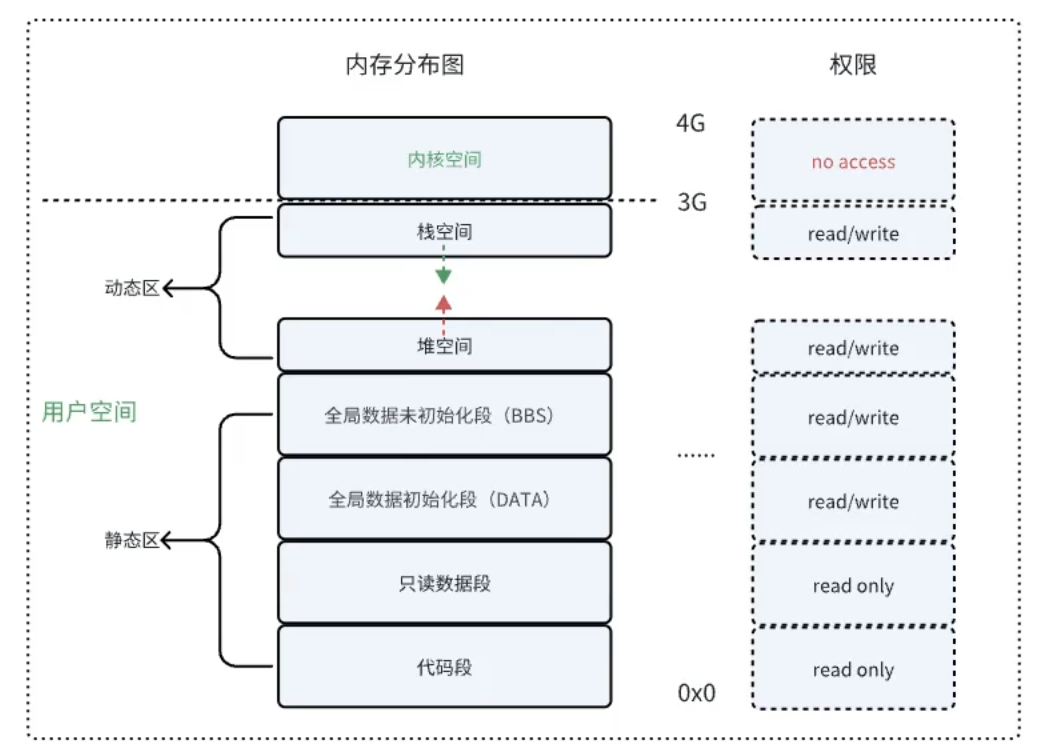

# 2. 内存四区

## 2.1 代码区

① 代码区：
1. 存放CPU执行的机器指令。
2. 代码区是共享的，共享的目的是对于频繁被执行的程序，只需要内存中有一份代码即可。
3. 代码区是只读的，使其只读的原因是防止程序员意外地修改了它的指令。写会触发Segmentationfault (core dumped)，俗称"段错误"。在整个程序生命周期内合法有效。
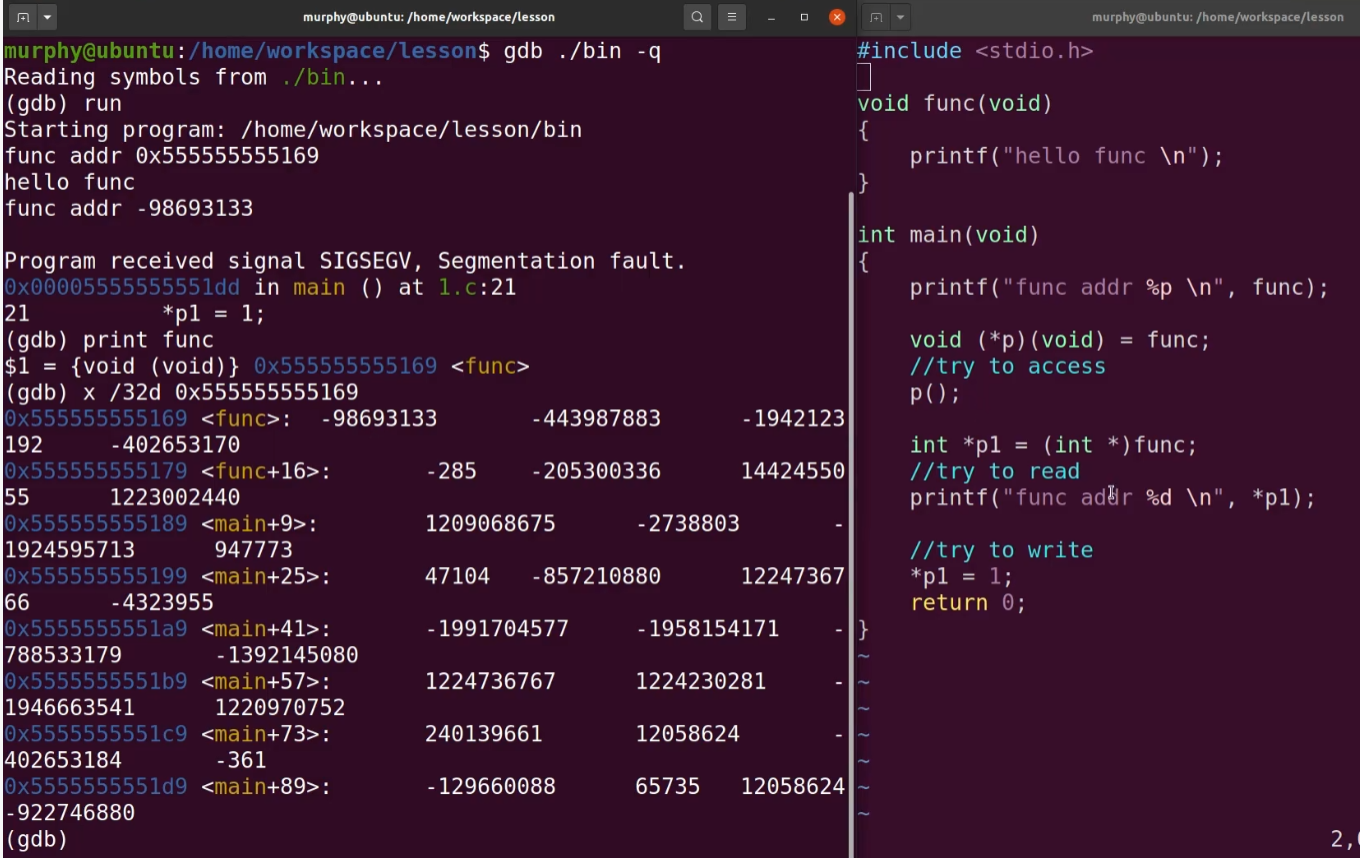

## 2.2 全局区/静态区

① 全局区：

1. 全局变量和静态变量存放在此，局部常量不放在全局区。
2. 全局区还包含了常量区，字符串常量和其他常量也存放在此。
3. 该区域的数据在程序结束后由操作系统释放。
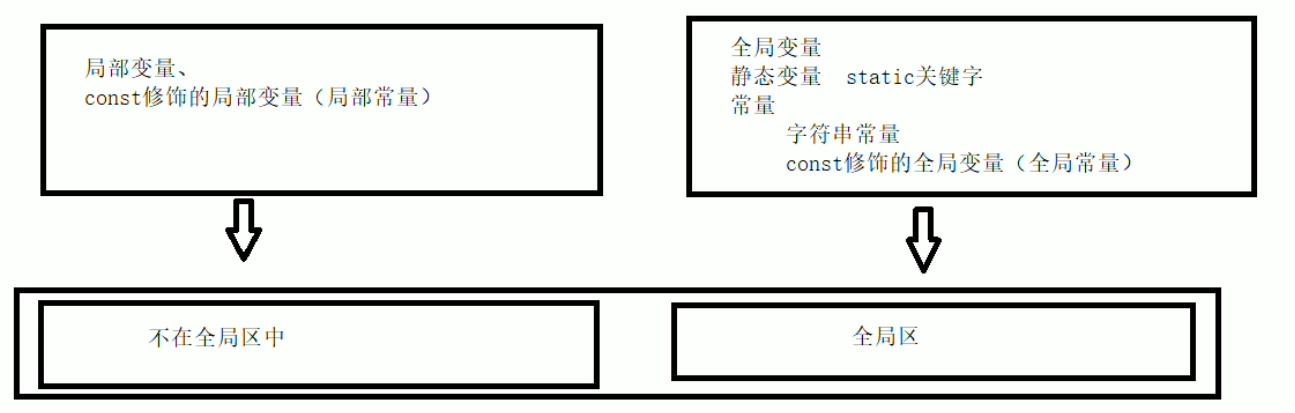

In [ ]:
#include <iostream>
using namespace std;

//全局变量 ，没有写在函数体中的变量全部称为全局变量
int g_a = 10;
int g_b = 20;

//const修饰的全局常量
const int c_g_a = 50;
const int c_g_b = 60;

int main()
{
    //全局区

    //全局变量、静态变量、常量

    //创建普通局部变量，写在函数体内的变量都叫做局部变量
    int a = 30;
    int b = 40;

    cout << "局部变量a的地址为：" << (int)&a << endl;
    cout << "局部变量b的地址为：" << (int)&b << endl;

    cout << "全局变量g_a的地址为：" << (int)&g_a << endl;
    cout << "全局变量g_b的地址为：" << (int)&g_b << endl;

    //静态变量  在普通变量前面加static,属于静态变量，静态变量不管是全局的还是局部的，都是存储在全局区的
    static int s_a = 10;
    static int s_b = 10;

    cout << "静态变量s_a的地址为：" << (int)&s_a << endl;
    cout << "静态变量s_b的地址为：" << (int)&s_b << endl;

    //常量
    //字符串常量
    cout << "字符串常量的地址为：" << (int)&"hello world" << endl;

    //const修饰的变量
    //const修饰的局部变量,const修饰的局部变量
    cout << "全局常量c_g_a的地址为：" << (int)&c_g_a << endl;
    cout << "全局常量c_g_a的地址为：" << (int)&c_g_b << endl;

    const int c_l_a = 10;  // c-const g-global  l-local;
    const int c_l_b = 10;
    cout << "局域常量c_l_a的地址为：" << (int)&c_l_a << endl;
    cout << "局域常量c_l_b的地址为：" << (int)&c_l_a << endl;

    system("pause");

    return 0;

}

运行结果：  
 - 局部变量a的地址为：14023100  
 - 局部变量b的地址为：14023088  
 - 全局变量g_a的地址为：4964352  
 - 全局变量g_b的地址为：4964356  
 - 静态变量s_a的地址为：4964360  
 - 静态变量s_b的地址为：4964364  
 - 字符串常量的地址为：4955128  
 - 全局常量c_g_a的地址为：4954928  
 - 全局常量c_g_a的地址为：4954932  
 - 局域常量c_l_a的地址为：14023076  
 - 局域常量c_l_b的地址为：14023076  
 - 请按任意键继续. . .

## 2.3 栈区

① 栈区

1. 由编译器自动分配释放，存放函数的参数值、局部变量等。
2. 不要返回局部变量的地址，栈区开辟的数据由编译器自动释放。

In [ ]:
#include <iostream>
using namespace std;

//栈区数据注意事项：不要返回局部变量的地址
//栈区的数据由编译器管理开辟和释放

int* func(int b)  //返回的是一个地址 int*；形参的数据也会放在栈区
{
    int a = 10;  //局部变量存放的数据10存放在栈区，栈区的数据在函数执行完后自动释放
    return &a;   //返回局部变量的地址，即数据10的的地址
}

int main()
{
    //接收func函数的返回值
    int* p = func(1);    //用指针接收栈区上的数据10的地址，由于栈区上数据10已经被释放，所以对地址解引用会获得乱码的值。

    cout << *p << endl;  //第一次可以 打印正确的数字，是因为编译器做了保留
    cout << *p << endl;  //第二次这个数据就不在保留了。

    system("pause");

    return 0;

}

运行结果：  
 - 10  
 - 1905325  
 - 请按任意键继续. . .

## 2.4 堆区

① 堆区：

1. 由程序员分配释放，若程序员不释放，程序结束时由操作系统回收。
2. 在C++中主要利用new在堆区开辟内存。
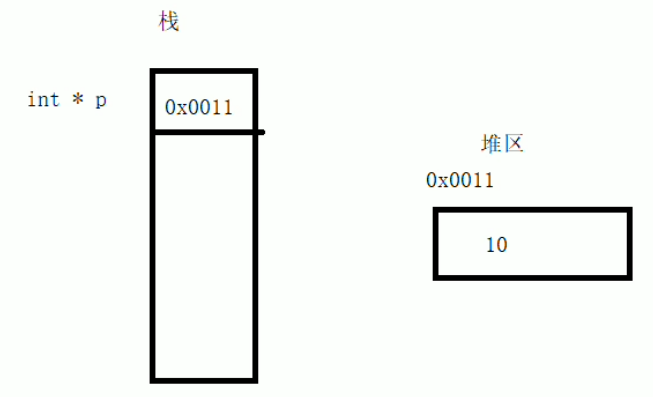

In [ ]:
#include <iostream>
using namespace std;

int* func()  //返回的是一个地址 int*；形参的数据也会放在栈区
{
    //利用new关键字，可以将数据开辟到堆区
    //指针本质也是变量，这里的指针是局部变量，局部变量的数据放在栈上，即指针保存的数据是放在堆区
    int * p = new int(10);   //new关键字会返回一个地址，因此用栈上的指针来接收堆上数据的地址。
    return p;
}
int main()
{
    //在堆区开辟数据
    int* p = func(); //堆区的地址返回给 *p 了，栈区数据是否，堆区数据没释放

    cout << *p << endl;
    cout << *p << endl;
    cout << *p << endl;
    cout << *p << endl;

    system("pause");

    return 0;

}

运行结果：  
 - 10  
 - 10  
 - 10  
 - 10  
 - 请按任意键继续. . .

## 2.5 堆栈的生长方向
栈（Stack）:增长方向	从高地址向低地址增长,内存布局	连续的栈帧结构
	
堆（Heap）:增长方向	从低地址向高地址增长,内存布局	不连续的内存块

func中的定义的两个变量的虽然a定义在b前面，但是实际分配空间的时候，不一定先给a分配空间
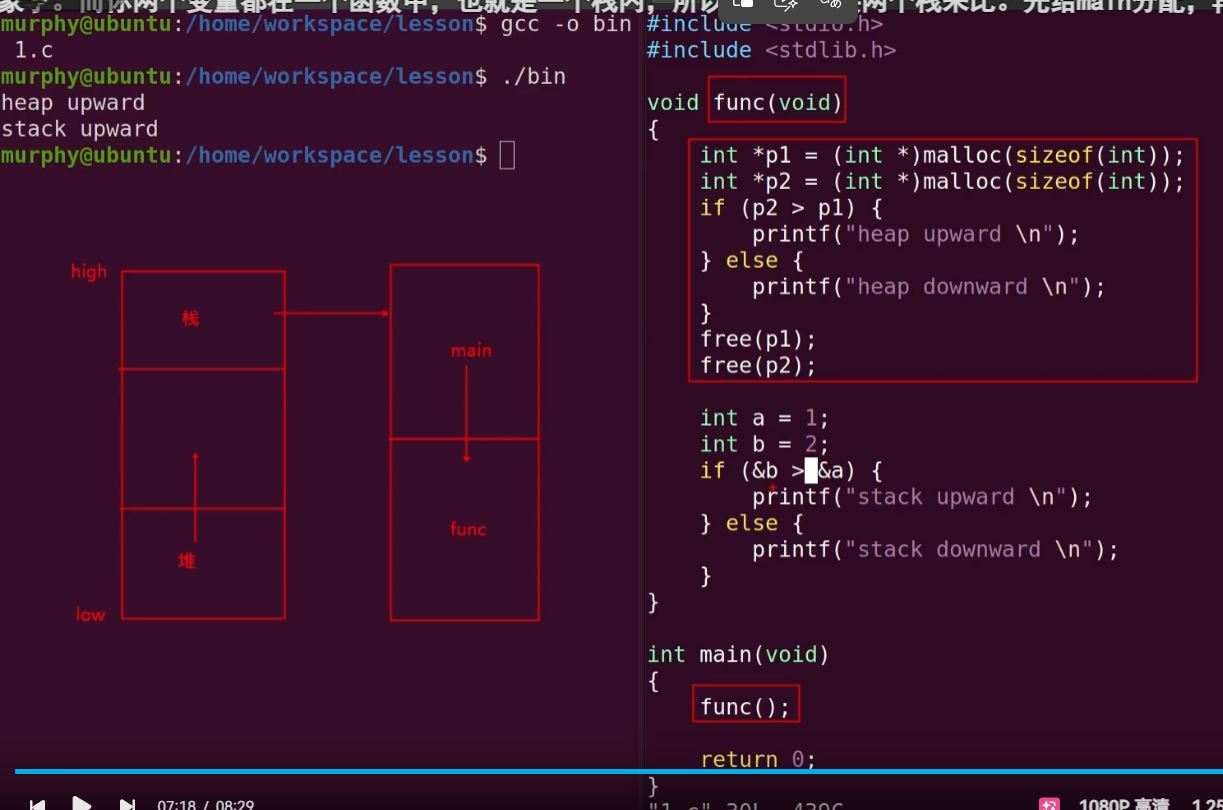
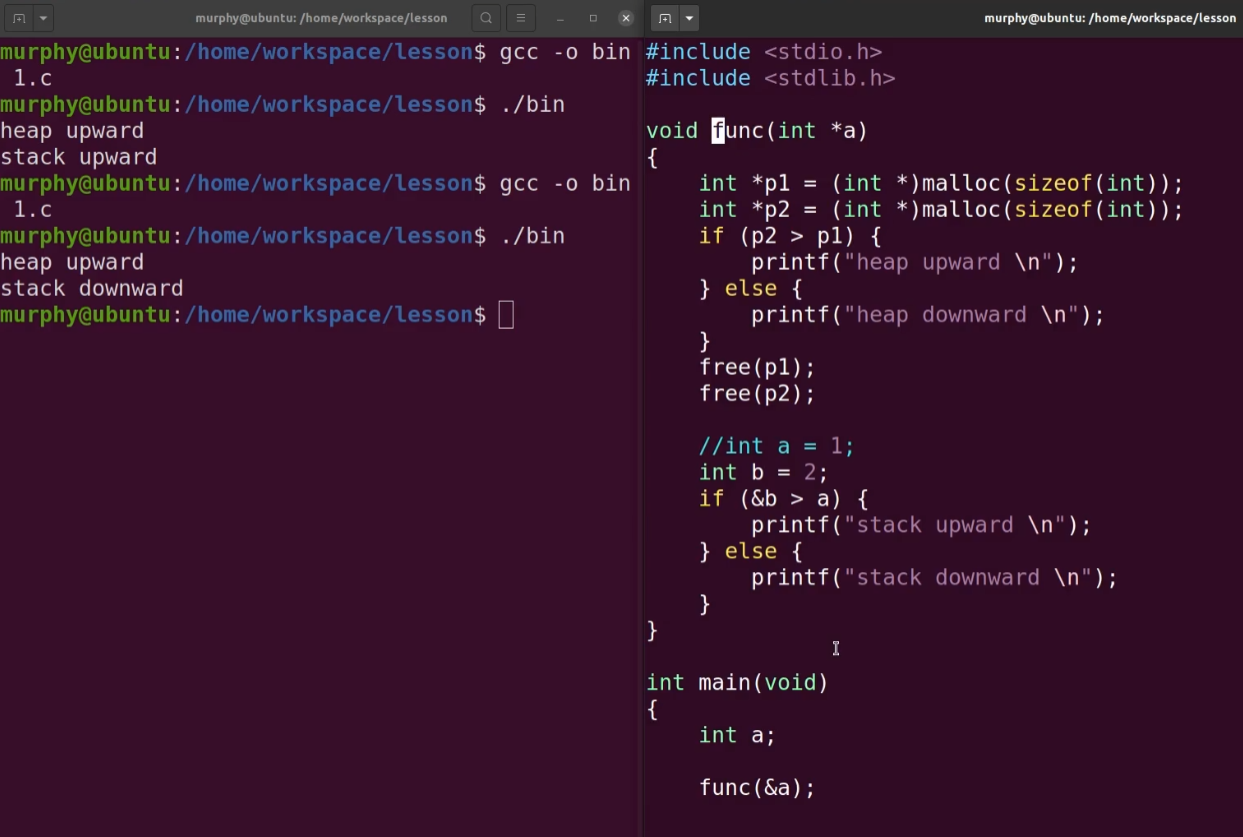

# 3. new操作符

① C++中利用new操作符在堆区开辟数据。

② 堆区开辟的数据，由程序员手动开辟，手动释放，释放利用操作符 delete。

③ 语法：new 数据类型

④ 利用new创建的数据，会返回该数据对应的类型的指针。

In [ ]:
#include <iostream>
using namespace std;

//1、new的基本语法

int* func()  //返回的是一个地址 int*；形参的数据也会放在栈区
{
    //在堆区创建整型数据
    //new返回是该数据类型的指针
    int* p = new int(10);
    return p;
}

void test01()
{
    int* p = func();
    cout << *p << endl;
    cout << *p << endl;
    cout << *p << endl;
    //堆区的数据，由程序员管理开辟，程序员管理释放
    //如果想释放堆区数据，利用关键字 delete
    delete p;

    // cout << *p << endl;  //报错，内存已经被释放，再次访问就是非法操作，会报错
}

//2、在堆区利用new开辟数据
void test02()
{
    //创建10整型数据的数组，在堆区
    int* arr = new int[10];//10代表数组有10个元素

    for (int i = 0; i < 10; i++)
    {
        arr[i] = i + 100; //给10个元素赋值 100~109
    }

    for (int i = 0; i < 10; i++)
    {
        cout << arr[i] << endl; 
    }
    //释放堆区数据
    //释放数组的时候，要加[]才可以
    delete[] arr;
}

int main()
{
    test01();
    test02();

    system("pause");

    return 0;

}

运行结果：  
 - 10  
 - 10  
 - 10  
 - 100  
 - 101  
 - 102  
 - 103  
 - 104  
 - 105  
 - 106  
 - 107  
 - 108  
 - 109  
 - 请按任意键继续. . .

# 4.内存溢出
内存溢出指的是程序运行过程中，访问超过其分配空间范围的内存区域。
## 4.1 栈溢出
可以通过ulimit -a命令查看当前系统的栈区大小，默认是8M，如果程序访问超过这个范围的内存，就会出现段错误。
- 递归函数:递归函数如果没有正常的退出条件，最后会把整个栈空间消耗殆尽，最后出现段错误。
   
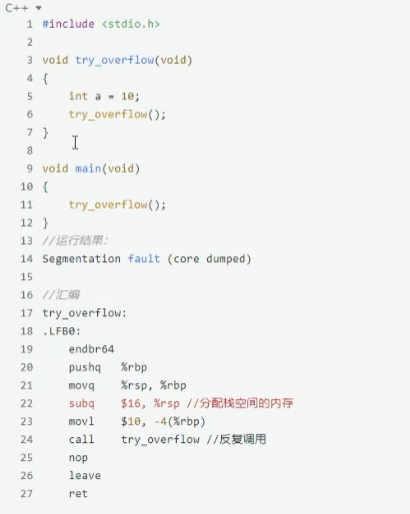
- 局部变量:如果定义的局部变量过大，超过了栈区的容量，也会出现段错误。

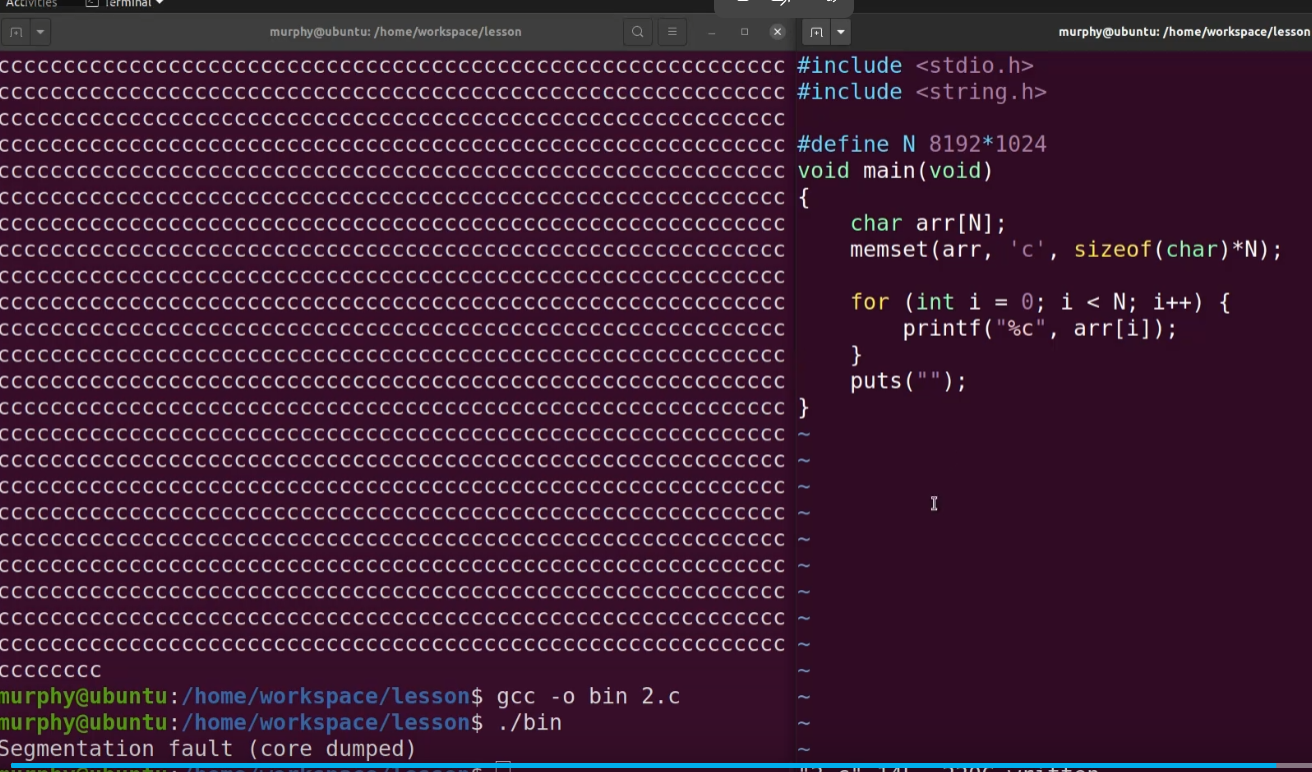


## 4.2 缓冲区溢出
缓冲区溢出指的是程序在向缓冲区写入数据时，超过了缓冲区的容量，导致数据覆盖了相邻内存区域的内容，可能会引发程序崩溃或者安全漏洞。
- 例如，定义一个字符数组作为缓冲区，如果输入的字符串长度超过了数组的容量，就会发生缓冲区溢出。

### 4.2.1 栈缓冲区溢出
栈缓冲区溢出是指在栈区发生的缓冲区溢出，通常是由于函数中的局部变量或参数数组被写入超过其定义的大小，导致覆盖了相邻的内存区域。这种溢出可能会破坏函数的返回地址、局部变量或者其他重要数据，从而引发程序崩溃或者被攻击者利用来执行恶意代码。
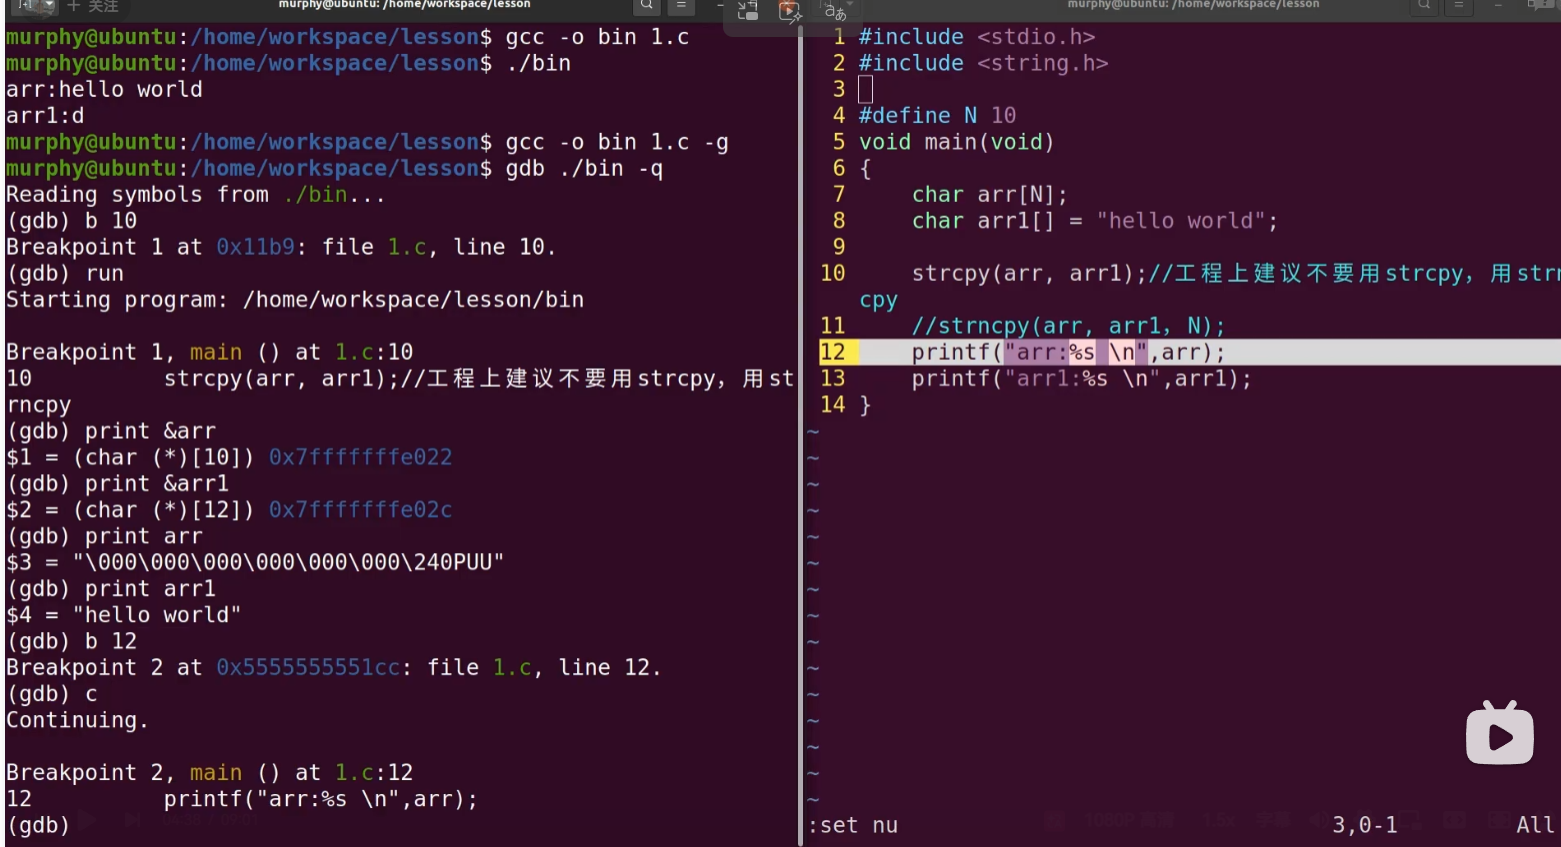
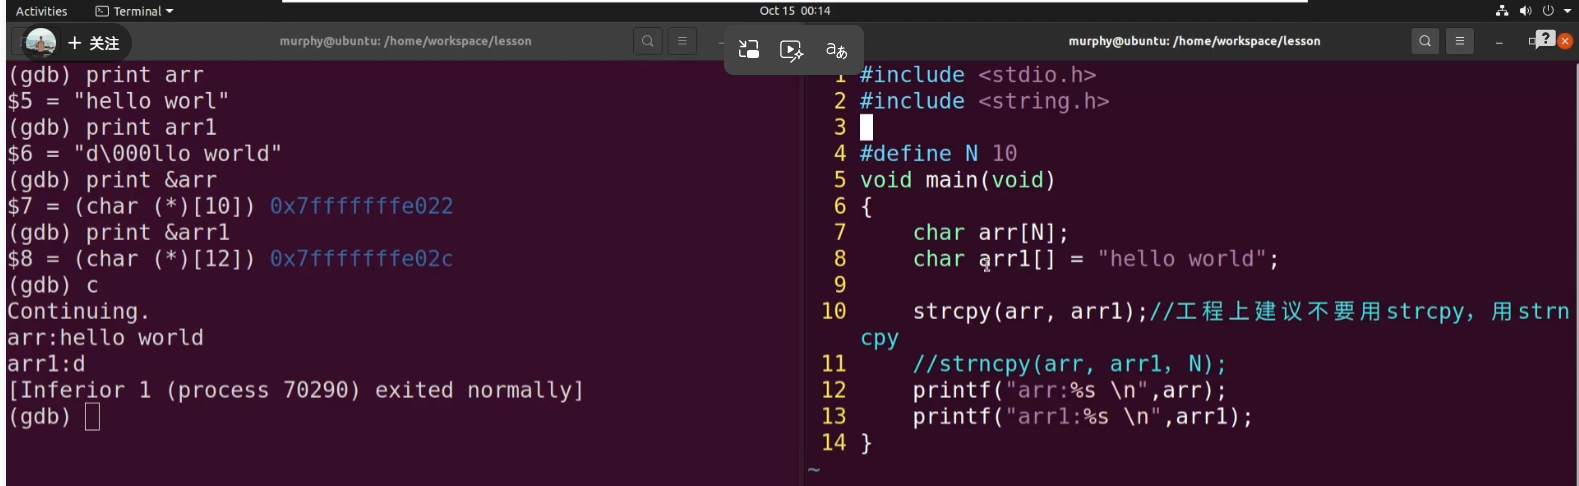


- 使用 strncpy 必须手动添加 '\0' 结束符！
正确的代码应该是这样的：
```c
运行
#define N 10
char arr[N];
char arr1[] = "hello world";
strncpy(arr, arr1, N-1); // 最多复制N-1个字节，留一个位置放'\0'
arr[N-1] = '\0';         // 手动添加结束符！这一步绝对不能少
```
执行后：
arr 的内容是：h e l l o w o r \0
printf 会正确输出：arr:hello wor

为什么 strncpy 设计得这么反人类？
这是历史遗留问题：
strncpy 最初是为了处理固定长度的字符串缓冲区设计的，比如 Unix 文件系统的文件名
这些缓冲区不需要 '\0' 结束符，只要填满就行
后来被误用为 "安全的字符串复制函数"，导致了无数 bug
- 更好的替代方案
1. 使用 strlcpy（推荐）
strlcpy 是专门为了解决 strncpy 的问题设计的，它总是会在目标字符串末尾添加 '\0'：
```c
strlcpy(arr, arr1, sizeof(arr));
```
注意：strlcpy 不是 C 标准库函数，但几乎所有 Unix/Linux 系统都支持。

### 4.2.2 堆缓冲区溢出
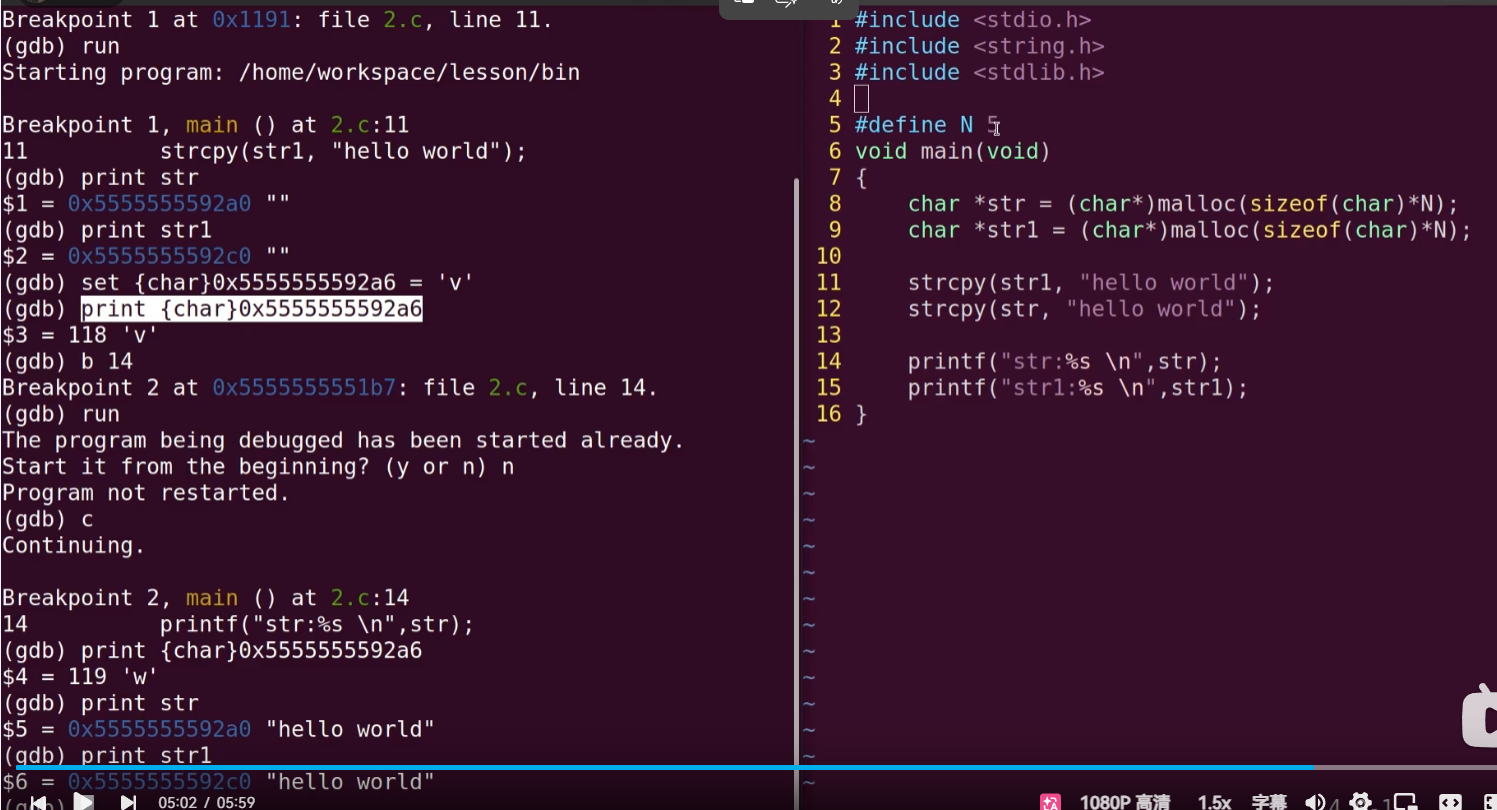